# Results walkthrough

A read-only tour of the evaluation artifacts this repository already ships. Every figure below is
computed from committed JSON and CSV under `reports/` - **no checkpoint is loaded and no inference is
run**, so the notebook executes in seconds on any machine that can `import matplotlib`.

For how to *reproduce* those artifacts, see `README.md` (local pipeline) and `COLAB_TRAINING.md`
(GPU runbook). For the interactive demo, see `notebooks/demo.ipynb`. This notebook answers a
different question: **what did the evaluation actually show?**

What follows, in order:

1. **Cross-domain transfer** - why the project needed SID adaptation at all
2. **Robustness** - how both checkpoints hold up under JPEG, blur, downscaling and noise
3. **Generator subgroups** - which kind of AI image is actually hard
4. **Branch ablation** - what the CLIP and forensic streams each contribute
5. **Test-time augmentation** - what the inference policy buys
6. **Error analysis** - what the residual mistakes look like

> **A note on sample sizes.** Sections 1-3 and 5 use the 2,000-image SID test split and the
> 20,000-image CIFAKE test split. Section 4 uses 200-image probes written by the notebook-scale
> ablation runs. They are not interchangeable, and each figure states which it is using.

## Setup

Imports, paths and the plotting theme. The palette is fixed here so colour means the same thing in
every figure: **blue is the deployed SID LoRA checkpoint, orange is the pre-SID CIFAKE checkpoint.**

The table this cell prints is the availability check - `reports/metrics/*.json` is committed, but
`reports/notebook/` may not be on a fresh clone. Cells whose inputs are missing print a note and skip
rather than failing.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve the repository root whether the kernel starts in the repo or in notebooks/.
ROOT = Path.cwd()
if not (ROOT / "reports").is_dir() and (ROOT.parent / "reports").is_dir():
    ROOT = ROOT.parent
METRICS = ROOT / "reports" / "metrics"
NB_REPORTS = ROOT / "reports" / "notebook"

# Palette: categorical slots 1-3 of the validated default palette, light surface.
# Colour follows the entity across every figure in this notebook:
#   BLUE = the deployed SID LoRA, ORANGE = the pre-SID CIFAKE checkpoint.
INK, INK_2, INK_MUTE = "#0b0b0b", "#52514e", "#8a8880"
SURFACE, GRID, NEUTRAL = "#fcfcfb", "#e6e5e1", "#b9b7b0"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "figure.dpi": 120,
    "savefig.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.linewidth": 0.8,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "axes.titlelocation": "left",
    "axes.titlepad": 10,
    "axes.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.linestyle": "-",          # solid hairline grid, never dashed
    "xtick.color": INK_MUTE,
    "ytick.color": INK_MUTE,
    "xtick.labelcolor": INK_2,
    "ytick.labelcolor": INK_2,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "legend.labelcolor": INK_2,
    "font.size": 9.5,
    "font.family": "sans-serif",
})


def load_json(path):
    # Return parsed JSON, or None when the artifact is absent.
    path = Path(path)
    if not path.is_file():
        return None
    with path.open() as fh:
        return json.load(fh)


def require(*objs):
    # Guard for cells that need artifacts which may not be present.
    missing = [o for o in objs if o is None]
    if missing:
        raise RuntimeError("required report artifact missing - see the availability table above")


ARTIFACTS = {
    "cifake_in_domain": METRICS / "pre_sid_cifake_robustness.json",
    "sid_before_lora": METRICS / "pre_sid_sid_holdout_robustness.json",
    "sid_after_lora": METRICS / "sid_local_lora_test_robustness.json",
    "sid_after_lora_tta": METRICS / "sid_local_lora_tta_test_robustness.json",
    "inference_policy": METRICS / "inference_policy_validation.json",
    "error_analysis": NB_REPORTS / "error_analysis.json",
    "demo_predictions": NB_REPORTS / "demo_predictions.json",
}

availability = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": str(p.relative_to(ROOT)),
            "found": "yes" if p.is_file() else "MISSING",
        }
        for name, p in ARTIFACTS.items()
    ]
)
availability

,artifact,path,found
0,cifake_in_domain,reports/metrics/pre_sid_cifake_robustness.json,yes
1,sid_before_lora,reports/metrics/pre_sid_sid_holdout_robustness...,yes
2,sid_after_lora,reports/metrics/sid_local_lora_test_robustness...,yes
3,sid_after_lora_tta,reports/metrics/sid_local_lora_tta_test_robust...,yes
4,inference_policy,reports/metrics/inference_policy_validation.json,yes
5,error_analysis,reports/notebook/error_analysis.json,yes
6,demo_predictions,reports/notebook/demo_predictions.json,yes


## 1. Cross-domain transfer is the whole problem

The single most important number in this project is not the in-domain score - it is what happens when
the CIFAKE-trained checkpoint meets a different data distribution.

All three rows below are the same evaluation code at each configuration's own tuned threshold.

In [2]:
cifake_in = load_json(ARTIFACTS["cifake_in_domain"])
sid_before = load_json(ARTIFACTS["sid_before_lora"])
sid_after = load_json(ARTIFACTS["sid_after_lora"])
sid_tta = load_json(ARTIFACTS["sid_after_lora_tta"])
require(cifake_in, sid_before, sid_after)

CONFIGS = [
    ("CIFAKE LoRA on CIFAKE test", cifake_in, "in-domain"),
    ("CIFAKE LoRA on SID test", sid_before, "cross-domain, before adaptation"),
    ("SID LoRA on SID test", sid_after, "cross-domain, after adaptation"),
]

headline = pd.DataFrame(
    [
        {
            "configuration": name,
            "regime": regime,
            "n": doc["transforms"]["clean"]["samples"],
            "auroc": doc["transforms"]["clean"]["auroc"],
            "balanced_acc": doc["transforms"]["clean"]["balanced_accuracy"],
            "recall": doc["transforms"]["clean"]["recall"],
            "fpr": doc["transforms"]["clean"]["false_positive_rate"],
        }
        for name, doc, regime in CONFIGS
    ]
)
headline.round(4)

,configuration,regime,n,auroc,balanced_acc,recall,fpr
0,CIFAKE LoRA on CIFAKE test,in-domain,20000,0.9970,0.9742,0.9801,0.0316
1,CIFAKE LoRA on SID test,"cross-domain, before adaptation",2000,0.7535,0.5875,0.9390,0.7640
2,SID LoRA on SID test,"cross-domain, after adaptation",2000,0.9427,0.8645,0.8910,0.1620


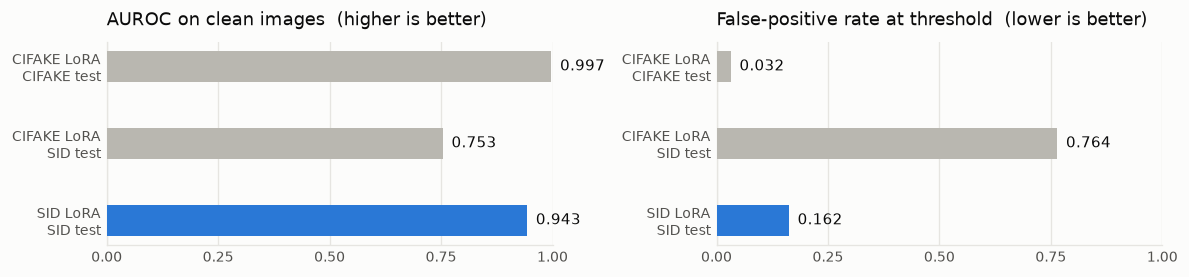

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 2.4))

# Emphasis rather than three hues: the deployed configuration is blue, its context neutral.
colours = [NEUTRAL, NEUTRAL, BLUE]
labels = ["CIFAKE LoRA\nCIFAKE test", "CIFAKE LoRA\nSID test", "SID LoRA\nSID test"]
y = np.arange(len(labels))[::-1]

panels = [
    ("AUROC on clean images  (higher is better)", "auroc"),
    ("False-positive rate at threshold  (lower is better)", "fpr"),
]

for ax, (title, col) in zip(axes, panels):
    vals = headline[col].to_numpy()
    ax.barh(y, vals, height=0.40, color=colours, zorder=3)
    for yi, v in zip(y, vals):
        ax.text(v + 0.02, yi, f"{v:.3f}", va="center", ha="left",
                fontsize=9, color=INK, zorder=4)
    ax.set_yticks(y, labels)
    ax.set_xlim(0, 1.0)
    ax.set_xticks(np.arange(0, 1.01, 0.25))
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

Read the false-positive column first. A detector that calls 76% of real photographs
AI-generated is not a weak detector, it is an unusable one, and the in-domain AUROC of 0.997 gives no
warning of it. This is the gap the SID LoRA stage exists to close.

## 2. Robustness under post-processing

Any real image has been through a pipeline - re-encoded, resized, maybe filtered. The evaluation
applies 14 perturbations to the same test split and re-scores.

Both models are evaluated on the **same 2,000-image SID test split**, so the two lines in each panel
are directly comparable.

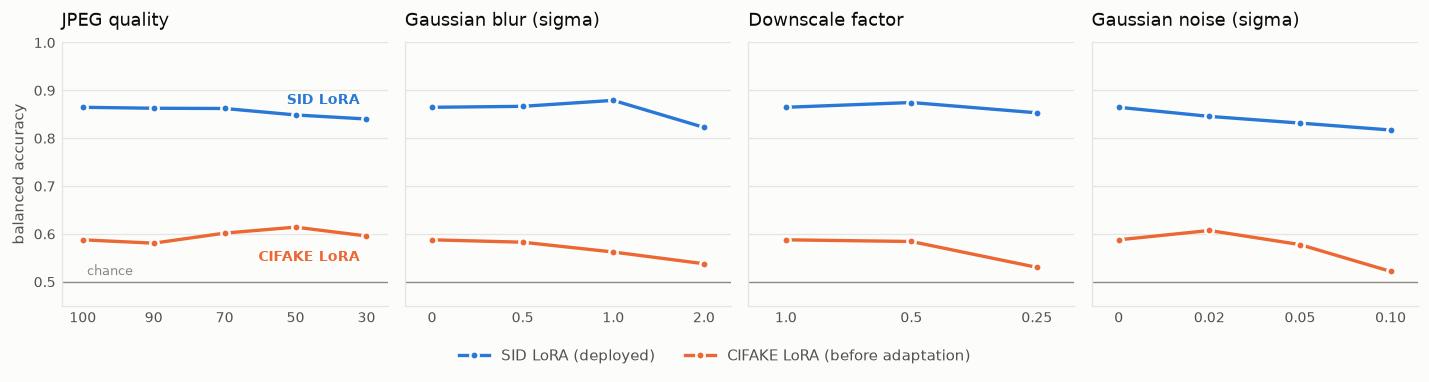

In [4]:
# Perturbation families, ordered mild -> severe. "clean" anchors each family at zero severity.
FAMILIES = {
    "JPEG quality": [("clean", "100"), ("jpeg_90", "90"), ("jpeg_70", "70"),
                     ("jpeg_50", "50"), ("jpeg_30", "30")],
    "Gaussian blur (sigma)": [("clean", "0"), ("blur_0.5", "0.5"), ("blur_1.0", "1.0"),
                              ("blur_2.0", "2.0")],
    "Downscale factor": [("clean", "1.0"), ("resize_0.5", "0.5"), ("resize_0.25", "0.25")],
    "Gaussian noise (sigma)": [("clean", "0"), ("noise_0.02", "0.02"),
                               ("noise_0.05", "0.05"), ("noise_0.10", "0.10")],
}

MODELS = [
    ("SID LoRA (deployed)", sid_after, BLUE),
    ("CIFAKE LoRA (before adaptation)", sid_before, ORANGE),
]

METRIC = "balanced_accuracy"

fig, axes = plt.subplots(1, 4, figsize=(12.0, 2.9), sharey=True)

for ax, (family, steps) in zip(axes, FAMILIES.items()):
    x = np.arange(len(steps))
    for name, doc, colour in MODELS:
        vals = [doc["transforms"][key][METRIC] for key, _ in steps]
        ax.plot(x, vals, color=colour, linewidth=2, marker="o", markersize=5,
                markeredgecolor=SURFACE, markeredgewidth=1.5, label=name, zorder=3)
    ax.axhline(0.5, color=INK_MUTE, linewidth=0.8, zorder=2)
    ax.set_xticks(x, [lab for _, lab in steps])
    ax.set_title(family)
    ax.set_xlim(-0.3, len(steps) - 0.7)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)

axes[0].set_ylim(0.45, 1.0)
axes[0].set_ylabel("balanced accuracy")
axes[0].text(0.06, 0.507, "chance", fontsize=8, color=INK_MUTE, va="bottom")

# Direct labels on the first facet; the SID LoRA line sits above the other throughout.
first = FAMILIES["JPEG quality"]
xi = len(first) - 1
axes[0].annotate("SID LoRA", (xi, sid_after["transforms"][first[xi][0]][METRIC]),
                 textcoords="offset points", xytext=(-4, 9), ha="right",
                 fontsize=8.5, color=BLUE, weight="bold")
axes[0].annotate("CIFAKE LoRA", (xi, sid_before["transforms"][first[xi][0]][METRIC]),
                 textcoords="offset points", xytext=(-4, -15), ha="right",
                 fontsize=8.5, color=ORANGE, weight="bold")

handles, labels_ = axes[0].get_legend_handles_labels()
fig.tight_layout()
fig.legend(handles, labels_, loc="lower center", bbox_to_anchor=(0.5, -0.10), ncols=2)
plt.show()

The shapes differ in kind, not just degree. The pre-adaptation model degrades
catastrophically under blur and downscaling - it was reading CIFAKE's 32x32 upsampling signature, and
resampling destroys it. The adapted model's worst case across all 14 perturbations is a 4.8-point drop
in balanced accuracy.

The full numbers, including the `color_0.2` and `crop_0.8` variants that are not in the curves above:

In [5]:
rows = []
for key in sid_after["transforms"]:
    row = {"transform": key}
    for name, doc, _ in MODELS:
        row[f"{name} auroc"] = doc["transforms"][key]["auroc"]
        row[f"{name} bal_acc"] = doc["transforms"][key]["balanced_accuracy"]
    rows.append(row)

robustness_table = pd.DataFrame(rows).set_index("transform")
robustness_table.round(4)

,SID LoRA (deployed) auroc,SID LoRA (deployed) bal_acc,CIFAKE LoRA (before adaptation) auroc,CIFAKE LoRA (before adaptation) bal_acc
transform,,,,
clean,0.9427,0.8645,0.7535,0.5875
jpeg_90,0.9394,0.8625,0.7510,0.5805
jpeg_70,0.9351,0.8620,0.7671,0.6015
jpeg_50,0.9308,0.8485,0.7656,0.6140
jpeg_30,0.9247,0.8400,0.7511,0.5955
blur_0.5,0.9456,0.8665,0.7502,0.5825
blur_1.0,0.9503,0.8790,0.7336,0.5620
blur_2.0,0.9059,0.8225,0.7101,0.5375
resize_0.5,0.9511,0.8745,0.7499,0.5840


## 3. Locally tampered images are the hard class

The SID test split is not homogeneous. It carries three subgroups, and averaging over them hides the
result that matters most for deployment.

In [6]:
def subgroup_frame(doc, model_name, variant="clean"):
    rows = []
    for entry in doc["transforms"][variant]["subgroups"].values():
        rows.append({
            "model": model_name,
            "generator": entry["generator"],
            "truth": "AI" if entry["binary_label"] == 1 else "real",
            "samples": entry["samples"],
            "accuracy": entry["accuracy"],
            "mean_probability": entry["mean_probability"],
        })
    return pd.DataFrame(rows)


subgroups = pd.concat([
    subgroup_frame(sid_after, "SID LoRA"),
    subgroup_frame(sid_before, "CIFAKE LoRA"),
], ignore_index=True)

order = ["openimages_v7", "full_synthetic", "tampered"]
subgroups.pivot(index="generator", columns="model", values="accuracy").loc[order].round(4)

model,CIFAKE LoRA,SID LoRA
generator,,
openimages_v7,0.236,0.838
full_synthetic,0.992,0.998
tampered,0.886,0.784


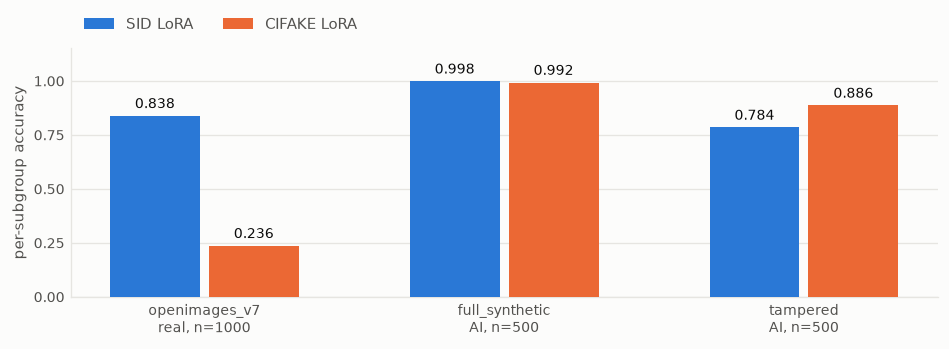

In [7]:
fig, ax = plt.subplots(figsize=(8.0, 3.0))

pivot = subgroups.pivot(index="generator", columns="model", values="accuracy").loc[order]
x = np.arange(len(order))
width = 0.30
series = [("SID LoRA", BLUE), ("CIFAKE LoRA", ORANGE)]

for i, (name, colour) in enumerate(series):
    # The gap between adjacent bars is surface, not a drawn border.
    offset = (i - 0.5) * (width + 0.03)
    vals = pivot[name].to_numpy()
    ax.bar(x + offset, vals, width=width, color=colour, label=name, zorder=3)
    for xi, v in zip(x + offset, vals):
        ax.text(xi, v + 0.02, f"{v:.3f}", ha="center", va="bottom",
                fontsize=8.5, color=INK, zorder=4)

counts = subgroups[subgroups.model == "SID LoRA"].set_index("generator").loc[order, "samples"]
truths = subgroups[subgroups.model == "SID LoRA"].set_index("generator").loc[order, "truth"]
ax.set_xticks(x, [f"{g}\n{t}, n={n}" for g, t, n in zip(order, truths, counts)])
ax.set_ylim(0, 1.15)
ax.set_yticks(np.arange(0, 1.01, 0.25))
ax.set_ylabel("per-subgroup accuracy")
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncols=2)

fig.tight_layout()
plt.show()

This is the most actionable finding in the evaluation. For the deployed model, fully
synthetic images are close to solved at 99.8%. **Locally tampered images** - real photographs with an
edited region - land 21 points lower, and they are also the more realistic threat model. An aggregate
accuracy figure averages that gap away.

The orange bars need reading with care. The pre-SID checkpoint scores *higher* than the deployed model
on both AI subgroups, but that is not skill: it calls almost everything AI, which is exactly why its
real-photograph accuracy is 0.236. Per-class accuracy is only interpretable alongside the false-positive
rate from section 1.

## 4. Branch ablation: the two streams are complementary

The detector has two feature streams: a CLIP semantic branch and a forensic branch. These arms were run
as 200-image probes, so they answer "do both streams contribute?" and not "by exactly how much".

Each row below is one branch configuration. The filled dot is its clean AUROC, the hollow dot its mean
across the 15 perturbations - so the length of the connector is that arm's robustness cost.

In [8]:
ARMS = [
    ("clip", NB_REPORTS / "ablation_clip" / "robustness_summary.csv", BLUE),
    ("forensic", NB_REPORTS / "ablation_forensic" / "robustness_summary.csv", ORANGE),
    ("clip+forensic", NB_REPORTS / "ablation_clip_forensic" / "robustness_summary.csv", AQUA),
]

ablation_rows = []
ablation_available = []
for name, path, colour in ARMS:
    if not path.is_file():
        continue
    df = pd.read_csv(path)
    clean = df[df.variant == "clean"]
    perturbed = df[df.variant != "clean"]
    ablation_rows.append({
        "branches": name,
        "n": int(clean["n"].iloc[0]),
        "clean_auroc": float(clean["auroc"].iloc[0]),
        "mean_perturbed_auroc": float(perturbed["auroc"].mean()),
        "worst_perturbed_auroc": float(perturbed["auroc"].min()),
        "clean_accuracy": float(clean["accuracy"].iloc[0]),
    })
    ablation_available.append((name, colour))

ablation = pd.DataFrame(ablation_rows)
ablation.round(4)

,branches,n,clean_auroc,mean_perturbed_auroc,worst_perturbed_auroc,clean_accuracy
0,clip,200,0.9020,0.8562,0.7804,0.835
1,forensic,200,0.9110,0.7917,0.5976,0.820
2,clip+forensic,200,0.9298,0.8733,0.7853,0.855


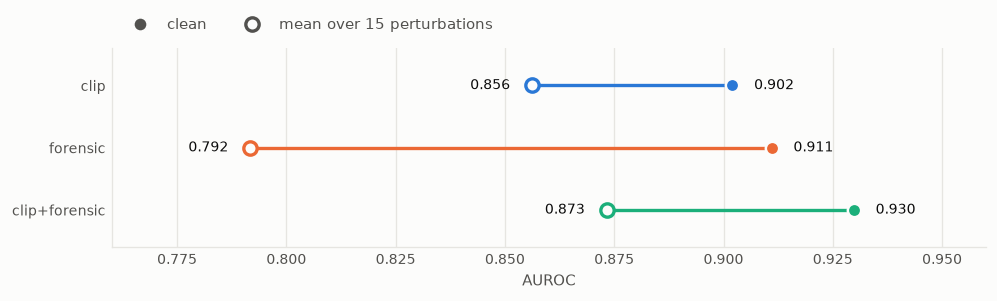

In [9]:
if ablation.empty:
    print("ablation artifacts not found under reports/notebook/ - skipping this figure")
else:
    from matplotlib.lines import Line2D

    fig, ax = plt.subplots(figsize=(8.4, 2.6))
    y = np.arange(len(ablation_available))[::-1]

    # A dot plot, not bars: these AUROC differences are small enough that the axis has to be
    # truncated to show them, and a truncated bar baseline would overstate the gaps.
    for yi, (name, colour) in zip(y, ablation_available):
        row = ablation[ablation.branches == name].iloc[0]
        lo, hi = row["mean_perturbed_auroc"], row["clean_auroc"]
        ax.plot([lo, hi], [yi, yi], color=colour, linewidth=2,
                solid_capstyle="round", zorder=3)
        ax.scatter([hi], [yi], s=64, color=colour, edgecolor=SURFACE,
                   linewidth=1.5, zorder=4)
        ax.scatter([lo], [yi], s=64, color=SURFACE, edgecolor=colour,
                   linewidth=2, zorder=4)
        # Every point is labelled: the aqua slot falls below 3:1 on this surface,
        # so the relief rule requires visible values.
        ax.text(hi + 0.005, yi, f"{hi:.3f}", va="center", ha="left",
                fontsize=8.5, color=INK, zorder=5)
        ax.text(lo - 0.005, yi, f"{lo:.3f}", va="center", ha="right",
                fontsize=8.5, color=INK, zorder=5)

    ax.set_yticks(y, [name for name, _ in ablation_available])
    ax.set_ylim(-0.6, len(ablation_available) - 0.4)
    ax.set_xlim(0.76, 0.96)
    ax.set_xlabel("AUROC")
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)

    proxies = [
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor=INK_2, markeredgecolor=SURFACE, label="clean"),
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor=SURFACE, markeredgecolor=INK_2,
               markeredgewidth=2, label="mean over 15 perturbations"),
    ]
    ax.legend(handles=proxies, loc="lower left", bbox_to_anchor=(0, 1.01), ncols=2)

    fig.tight_layout()
    plt.show()

Neither stream dominates alone, and the combination beats both on clean data and on the
perturbation mean - which is the argument for keeping the two-branch design. Note also that the forensic
branch has by far the longest connector: on its own it is the most perturbation-sensitive arm, and
pairing it with CLIP is what stabilises it.

At n=200 these gaps are within sampling noise. The ordering is consistent; the magnitudes are not
precise, and none of these numbers should be quoted next to the 2,000-image results above.

## 5. What test-time augmentation buys

The deployed inference policy averages predictions over 5 transforms with a trimmed mean. The question
is whether that is worth roughly 5x the inference cost.

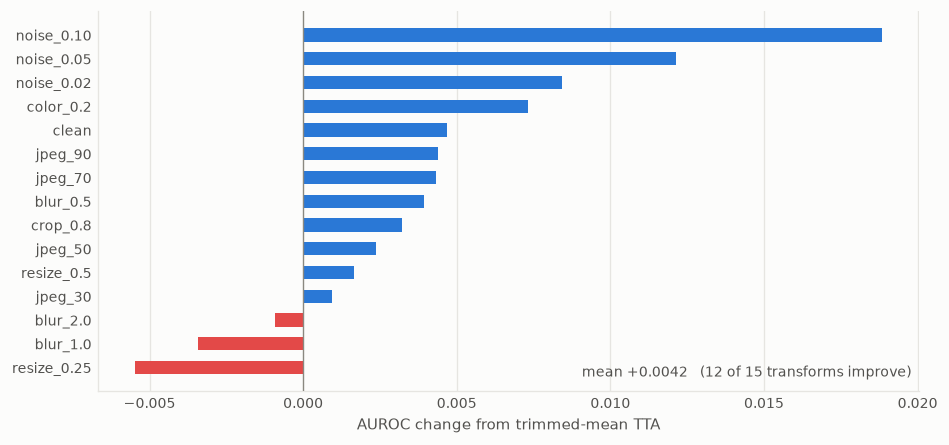

,single,tta,delta
transform,,,
resize_0.25,0.9236,0.9181,-0.0055
blur_1.0,0.9503,0.9469,-0.0034
blur_2.0,0.9059,0.9049,-0.0009
jpeg_30,0.9247,0.9256,0.0009
resize_0.5,0.9511,0.9528,0.0017
jpeg_50,0.9308,0.9332,0.0024
crop_0.8,0.9430,0.9462,0.0032
blur_0.5,0.9456,0.9496,0.0039
jpeg_70,0.9351,0.9394,0.0043


In [10]:
if sid_tta is None:
    print("TTA robustness artifact not found - skipping this figure")
else:
    shared = [t for t in sid_after["transforms"] if t in sid_tta["transforms"]]
    deltas = pd.DataFrame([
        {
            "transform": t,
            "single": sid_after["transforms"][t]["auroc"],
            "tta": sid_tta["transforms"][t]["auroc"],
            "delta": sid_tta["transforms"][t]["auroc"] - sid_after["transforms"][t]["auroc"],
        }
        for t in shared
    ]).sort_values("delta")

    fig, ax = plt.subplots(figsize=(8.0, 3.8))
    # Diverging encoding about a true zero: one cool pole for gains, one warm for losses.
    colours = [BLUE if d >= 0 else RED for d in deltas["delta"]]
    y = np.arange(len(deltas))
    ax.barh(y, deltas["delta"], height=0.55, color=colours, zorder=3)
    ax.axvline(0, color=INK_MUTE, linewidth=0.8, zorder=4)
    ax.set_yticks(y, deltas["transform"])
    ax.set_xlabel("AUROC change from trimmed-mean TTA")
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)

    mean_delta = deltas["delta"].mean()
    n_up = int((deltas["delta"] > 0).sum())
    ax.text(0.99, 0.03, f"mean {mean_delta:+.4f}   ({n_up} of {len(deltas)} transforms improve)",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5, color=INK_2)

    fig.tight_layout()
    plt.show()
    display(deltas.set_index("transform").round(4))

A mean gain of about +0.004 AUROC, and it is not free everywhere: the three noise settings
gain the most (up to +0.019), while downscaling and blur lose a little. That pattern is consistent with
TTA averaging away high-frequency noise but compounding information that resampling has already
destroyed.

Worth keeping when latency is not binding, and the first thing to drop when it is.

## 6. What the residual errors look like

The error analysis was written against the CIFAKE test split at a threshold tuned for 5% FPR.

One caveat the artifact itself imposes: it records **every** false positive but only a sample of the
false negatives, and the recorded sample is the lowest-scoring end. The chart labels both rows with
their coverage so the second row is not read as a complete distribution.

operating threshold 0.9819 (tuned for <= 5% FPR on clean data)


,error type,total,recorded in artifact
0,false positives,5,5
1,false negatives,41,15


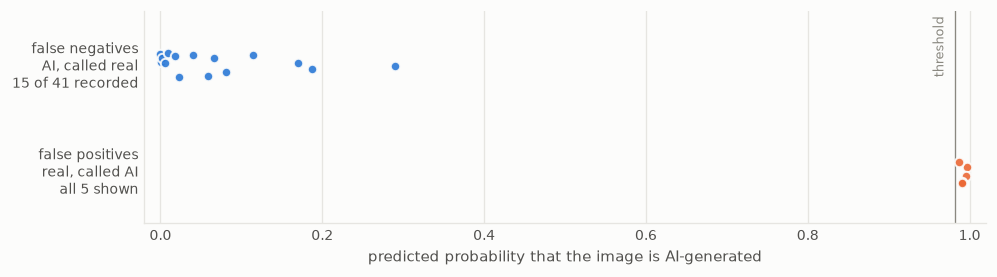

In [11]:
errors = load_json(ARTIFACTS["error_analysis"])
if errors is None:
    print("reports/notebook/error_analysis.json not found - skipping the error analysis")
else:
    thr = errors["threshold"]
    fps = pd.DataFrame(errors["false_positives"])
    fns = pd.DataFrame(errors["false_negatives"])

    # The artifact records every false positive but only a sample of the false negatives.
    # That truncation has to be on the chart, or the FN row reads as a full distribution.
    coverage = pd.DataFrame([
        {"error type": "false positives", "total": errors["n_false_positives"],
         "recorded in artifact": len(fps)},
        {"error type": "false negatives", "total": errors["n_false_negatives"],
         "recorded in artifact": len(fns)},
    ])
    print(f"operating threshold {thr:.4f} (tuned for <= {errors['target_fpr']:.0%} FPR on clean data)")
    display(coverage)

    fig, ax = plt.subplots(figsize=(8.4, 2.4))
    rng = np.random.default_rng(0)
    groups = [
        (f"false positives\nreal, called AI\nall {errors['n_false_positives']} shown", fps, ORANGE),
        (f"false negatives\nAI, called real\n{len(fns)} of {errors['n_false_negatives']} recorded", fns, BLUE),
    ]
    for i, (label, frame, colour) in enumerate(groups):
        if frame.empty:
            continue
        jitter = rng.uniform(-0.12, 0.12, len(frame))
        ax.scatter(frame["pred_prob"], np.full(len(frame), i) + jitter, s=32,
                   color=colour, edgecolor=SURFACE, linewidth=1.2, alpha=0.9, zorder=3)

    ax.axvline(thr, color=INK_MUTE, linewidth=0.8, zorder=2)
    ax.annotate("threshold", (thr, 1.45), textcoords="offset points", xytext=(-5, 0),
                rotation=90, ha="right", va="top", fontsize=8, color=INK_MUTE)
    ax.set_yticks([0, 1], [groups[0][0], groups[1][0]])
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlim(-0.02, 1.02)
    ax.set_xlabel("predicted probability that the image is AI-generated")
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)

    fig.tight_layout()
    plt.show()

All five false positives sit above p(AI) = 0.987 - the model is not hesitating on them, it
is confidently wrong. The same holds for the 15 recorded false negatives, though those were selected as
the most extreme, so they establish that at least 15 of the 41 misses are confident ones rather than
characterising all 41.

Either way, no threshold move recovers these cases: they are on the wrong side by a wide margin.

If the dataset is present locally, the failing images themselves follow. `data/` is gitignored, so on a
fresh clone this cell prints the file list instead.

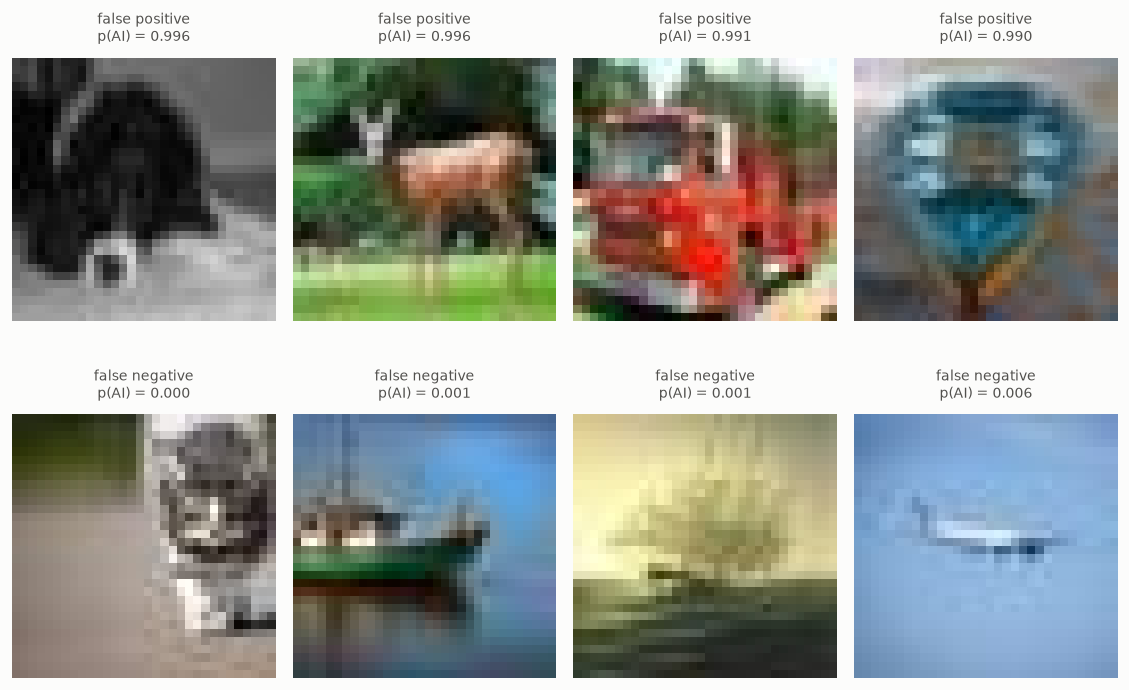

In [12]:
# The CIFAKE test images live under data/, which is gitignored - this grid renders
# only on a machine that has the dataset locally.
if errors is None:
    print("no error analysis to illustrate")
else:
    from PIL import Image

    picks = (
        [("false positive", r) for r in errors["false_positives"][:4]]
        + [("false negative", r) for r in errors["false_negatives"][:4]]
    )
    resolved = [(kind, r, ROOT / r["image_path"]) for kind, r in picks]
    present = [t for t in resolved if t[2].is_file()]

    if not present:
        print("dataset images not available locally (data/ is gitignored) - listing the cases instead")
        display(pd.DataFrame(
            [{"kind": k, "image": r["image_path"], "pred_prob": r["pred_prob"]} for k, r in picks]
        ).round(6))
    else:
        cols = 4
        rows = int(np.ceil(len(present) / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(9.5, 3.1 * rows))
        for ax, (kind, rec, path) in zip(np.ravel(axes), present):
            ax.imshow(Image.open(path).convert("RGB"))
            ax.set_title(f"{kind}\np(AI) = {rec['pred_prob']:.3f}", fontsize=8.5,
                         color=INK_2, loc="center")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.grid(visible=False)
            for spine in ax.spines.values():
                spine.set_visible(False)
        for ax in np.ravel(axes)[len(present):]:
            ax.set_visible(False)
        fig.tight_layout(h_pad=2.4)
        plt.show()

## Provenance

Which artifact produced which figure, and the checkpoints behind them. Everything above is
reproducible from a clone plus `reports/` - re-running any of it requires the pipeline in `README.md`.

In [13]:
provenance = pd.DataFrame([
    {"figure": "1 - cross-domain transfer",
     "source": "reports/metrics/{pre_sid_cifake,pre_sid_sid_holdout,sid_local_lora_test}_robustness.json"},
    {"figure": "2 - robustness curves",
     "source": "reports/metrics/{pre_sid_sid_holdout,sid_local_lora_test}_robustness.json"},
    {"figure": "3 - generator subgroups",
     "source": "same two files, transforms.clean.subgroups"},
    {"figure": "4 - branch ablation",
     "source": "reports/notebook/ablation_{clip,forensic,clip_forensic}/robustness_summary.csv"},
    {"figure": "5 - test-time augmentation",
     "source": "reports/metrics/sid_local_lora_{test,tta_test}_robustness.json"},
    {"figure": "6 - error analysis",
     "source": "reports/notebook/error_analysis.json"},
])

checkpoints = pd.DataFrame([
    {"role": "deployed", "checkpoint": sid_after["checkpoint"],
     "threshold": sid_after["threshold"], "manifest": sid_after.get("manifest", "-")},
    {"role": "pre-SID baseline", "checkpoint": sid_before["checkpoint"],
     "threshold": sid_before["threshold"], "manifest": sid_before.get("manifest", "-")},
])

display(provenance)
display(checkpoints)

,figure,source
0,1 - cross-domain transfer,"reports/metrics/{pre_sid_cifake,pre_sid_sid_ho..."
1,2 - robustness curves,"reports/metrics/{pre_sid_sid_holdout,sid_local..."
2,3 - generator subgroups,"same two files, transforms.clean.subgroups"
3,4 - branch ablation,"reports/notebook/ablation_{clip,forensic,clip_..."
4,5 - test-time augmentation,"reports/metrics/sid_local_lora_{test,tta_test}..."
5,6 - error analysis,reports/notebook/error_analysis.json


,role,checkpoint,threshold,manifest
0,deployed,checkpoints/sid_local_lora/sid_local_lora_best.pt,0.499196,data/manifests/sid_test.csv
1,pre-SID baseline,checkpoints/full_cifake_lora/full_cifake_lora_...,0.800249,data/manifests/sid_test.csv
